In [1]:
import kagglehub
path = kagglehub.dataset_download("jangedoo/utkface-new")

In [2]:
# ===================== PART 1: SETUP (Colab GPU) =====================
!pip install -q albumentations tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import pandas as pd
import numpy as np
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import os
import zipfile
from pathlib import Path

# Use GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using: {device}")
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ No GPU detected. Please go to Runtime -> Change runtime type and select 'GPU' for hardware accelerator.")

✅ Using: cuda
GPU Name: Tesla T4


In [3]:
# ===================== PART 2: LOAD UTKFACE =====================

# The UTKFace dataset is downloaded via kagglehub and its content is typically
# found under the 'UTKFace' subdirectory within the downloaded path.
utk_folder = os.path.join(path, "UTKFace")

data = []

print("Loading UTKFace images...")
for filename in tqdm(os.listdir(utk_folder)):
    if filename.endswith('.jpg'):
        try:
            parts = filename.split('_')
            age = int(parts[0])
            gender = int(parts[1])  # 0=Male, 1=Female

            data.append({
                'image_path': os.path.join(utk_folder, filename),
                'age': age,
                'gender': gender
            })
        except:
            continue

df = pd.DataFrame(data)
print(f"\nTotal Images: {len(df)}")

# Split
train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['gender'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['gender'])

print(f"Train: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")

Loading UTKFace images...


100%|██████████| 23708/23708 [00:00<00:00, 451345.16it/s]


Total Images: 23708
Train: 18966 | Validation: 2371 | Test: 2371


In [4]:
# ===================== PART 3: MODEL + DATASET (Fixed) =====================

# ------------------- Dataset Class -------------------
class AgeGenderDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        img = np.array(img)

        if self.transform:
            augmented = self.transform(image=img)
            img = augmented['image']

        age = torch.tensor(float(row['age']), dtype=torch.float32)
        gender = torch.tensor(row['gender'], dtype=torch.long)

        return img, age, gender

# ------------------- Augmentations (Fixed) -------------------
train_transform = A.Compose([
    A.RandomResizedCrop(size=(224, 224), scale=(0.7, 1.0)),
    A.HorizontalFlip(p=0.5),
    # Using Affine to avoid the ShiftScaleRotate warning
    A.Affine(translate_percent={"x": 0.1, "y": 0.1}, scale=0.9, rotate=20, p=0.5), 
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
    # Fixed GaussNoise: Using 'std_range' or simpler 'mean' for newer versions
    A.GaussNoise(std_range=(0.1, 0.3), p=0.3), 
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(height=256, width=256),
    A.CenterCrop(height=224, width=224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# ------------------- Multi-Task Model -------------------
class AgeGenderModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.efficientnet_b3(weights='IMAGENET1K_V1')
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        self.dropout = nn.Dropout(0.5)

        self.gender_head = nn.Linear(in_features, 2)
        self.age_head = nn.Linear(in_features, 1)   # Regression

    def forward(self, x):
        x = self.backbone(x)
        x = self.dropout(x)
        gender_out = self.gender_head(x)
        age_out = self.age_head(x)
        return gender_out, age_out

model = AgeGenderModel().to(device)
print("✅ Model (EfficientNet-B3) Created Successfully!")
print("Total Parameters:", sum(p.numel() for p in model.parameters()))

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 184MB/s]


✅ Model (EfficientNet-B3) Created Successfully!
Total Parameters: 10700843


In [7]:
import os
import pandas as pd
from tqdm import tqdm

# Correct Path
utk_folder = "/kaggle/input/datasets/jangedoo/utkface-new/UTKFace"

data = []

print("Scanning UTKFace folder...")

for filename in tqdm(os.listdir(utk_folder)):
    if filename.endswith('.jpg'):
        try:
            parts = filename.split('_')
            age = int(parts[0])
            gender = int(parts[1])   # 0 = Male, 1 = Female
            
            data.append({
                'image_path': os.path.join(utk_folder, filename),
                'age': age,
                'gender': gender
            })
        except:
            continue

df = pd.DataFrame(data)
print(f"\nTotal images processed: {len(df)}")

# Gender Distribution
print("\n=== GENDER DISTRIBUTION ===")
print(df['gender'].value_counts())
print("0 = Male | 1 = Female")
print(f"Male Percentage:   {(df['gender'] == 0).sum()/len(df)*100 :.2f}%")
print(f"Female Percentage: {(df['gender'] == 1).sum()/len(df)*100 :.2f}%")

# Save CSV
df.to_csv('/kaggle/working/utk_labels.csv', index=False)
print("\n✅ CSV file saved successfully at: /kaggle/working/utk_labels.csv")

Scanning UTKFace folder...


100%|██████████| 23708/23708 [00:00<00:00, 489088.60it/s]



Total images processed: 23708

=== GENDER DISTRIBUTION ===
gender
0    12391
1    11317
Name: count, dtype: int64
0 = Male | 1 = Female
Male Percentage:   52.27%
Female Percentage: 47.73%

✅ CSV file saved successfully at: /kaggle/working/utk_labels.csv


In [8]:
# ===================== PART 4: TRAINING WITH EARLY STOPPING (Optimized) =====================

train_dataset = AgeGenderDataset(train_df, transform=train_transform)
val_dataset = AgeGenderDataset(val_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# Loss, Optimizer
criterion_gender = nn.CrossEntropyLoss()
criterion_age = nn.SmoothL1Loss()

# 1. Optimizer with higher weight decay to fight overfitting
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

# 2. Scheduler to fine-tune the model when progress plateaus
# (Fixed: Removed verbose argument for compatibility)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# ===================== EARLY STOPPING =====================
patience = 6
best_val_mae = float('inf')
epochs_no_improve = 0
early_stop = False

num_epochs = 30 # Increased to 30 to allow the scheduler time to work

for epoch in range(num_epochs):
    if early_stop:
        break
        
    model.train()
    train_loss = 0.0
    correct_gender = 0
    total_gender = 0
    age_mae_sum = 0.0
    
    for images, ages, genders in tqdm(train_loader):
        images = images.to(device)
        ages = ages.to(device).unsqueeze(1)
        genders = genders.to(device)
        
        optimizer.zero_grad()
        
        gender_pred, age_pred = model(images)
        
        loss_gender = criterion_gender(gender_pred, genders)
        loss_age = criterion_age(age_pred, ages)
        total_loss = loss_gender + 0.8 * loss_age
        
        total_loss.backward()
        optimizer.step()
        
        train_loss += total_loss.item()
        _, predicted_gender = torch.max(gender_pred, 1)
        correct_gender += (predicted_gender == genders).sum().item()
        total_gender += genders.size(0)
        age_mae_sum += torch.mean(torch.abs(age_pred - ages)).item()
    
    # Validation Phase
    model.eval()
    val_gender_correct = 0
    val_total = 0
    val_age_mae = 0.0
    
    with torch.no_grad():
        for images, ages, genders in val_loader:
            images = images.to(device)
            ages = ages.to(device).unsqueeze(1)
            genders = genders.to(device)
            
            gender_pred, age_pred = model(images)
            
            _, predicted = torch.max(gender_pred, 1)
            val_gender_correct += (predicted == genders).sum().item()
            val_total += genders.size(0)
            val_age_mae += torch.mean(torch.abs(age_pred - ages)).item()
    
    avg_val_mae = val_age_mae / len(val_loader)
    
    # 3. Step the scheduler using the validation MAE
    scheduler.step(avg_val_mae)
    
    # Get current learning rate for logging
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"LR: {current_lr:.6f} | Train Loss: {train_loss/len(train_loader):.4f} | Gender Acc: {100*correct_gender/total_gender:.2f}%")
    print(f"Val Gender Acc: {100*val_gender_correct/val_total:.2f}% | Val Age MAE: {avg_val_mae:.4f}")
    
    # Early Stopping Check
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        epochs_no_improve = 0
        # Saving with a unique name
        torch.save(model.state_dict(), '/kaggle/working/best_age_gender_model_optimized.pth')
        print(f"✅ Best model saved! (Val MAE: {best_val_mae:.4f})")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s)")
        
        if epochs_no_improve >= patience:
            print(f"\n🛑 Early Stopping triggered! No improvement for {patience} epochs.")
            early_stop = True

print("\n🎉 Training Completed!")
print(f"Best Validation Age MAE: {best_val_mae:.4f}")


100%|██████████| 593/593 [03:16<00:00,  3.02it/s]



Epoch [1/30]
LR: 0.000100 | Train Loss: 12.6690 | Gender Acc: 71.46%
Val Gender Acc: 82.58% | Val Age MAE: 6.3989
✅ Best model saved! (Val MAE: 6.3989)


100%|██████████| 593/593 [03:16<00:00,  3.01it/s]



Epoch [2/30]
LR: 0.000100 | Train Loss: 6.0668 | Gender Acc: 80.10%
Val Gender Acc: 86.88% | Val Age MAE: 5.5459
✅ Best model saved! (Val MAE: 5.5459)


100%|██████████| 593/593 [03:16<00:00,  3.01it/s]


...


Epoch [25/30]
LR: 0.000050 | Train Loss: 3.0485 | Gender Acc: 92.71%
Val Gender Acc: 92.83% | Val Age MAE: 4.7805
No improvement for 4 epoch(s)


100%|██████████| 593/593 [03:16<00:00,  3.02it/s]



Epoch [26/30]
LR: 0.000050 | Train Loss: 2.9087 | Gender Acc: 92.93%
Val Gender Acc: 93.17% | Val Age MAE: 4.6715
No improvement for 5 epoch(s)


100%|██████████| 593/593 [03:16<00:00,  3.02it/s]



Epoch [27/30]
LR: 0.000050 | Train Loss: 2.7925 | Gender Acc: 92.97%
Val Gender Acc: 93.42% | Val Age MAE: 4.7122
No improvement for 6 epoch(s)

🛑 Early Stopping triggered! No improvement for 6 epochs.

🎉 Training Completed!
Best Validation Age MAE: 4.6652


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, mean_absolute_error, mean_squared_error
import numpy as np

# 1. Prepare Test Loader
test_dataset = AgeGenderDataset(test_df, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 2. Load Best Model
model.load_state_dict(torch.load('/kaggle/working/best_age_gender_model_optimized.pth'))
model.eval()
model.to(device)

all_gender_preds = []
all_gender_true = []
all_age_preds = []
all_age_true = []

print("📊 Evaluating on Test Set...")
with torch.no_grad():
    for images, ages, genders in tqdm(test_loader):
        images = images.to(device)
        
        # NOTE: Using the order from your loop: gender first, then age
        gender_logits, age_pred = model(images)
        
        # Gender Predictions
        _, predicted = torch.max(gender_logits, 1)
        all_gender_preds.extend(predicted.cpu().numpy())
        all_gender_true.extend(genders.numpy())
        
        # Age Predictions
        all_age_preds.extend(age_pred.cpu().numpy().flatten())
        all_age_true.extend(ages.numpy())

# Convert to arrays
all_gender_preds = np.array(all_gender_preds)
all_gender_true = np.array(all_gender_true)
all_age_preds = np.array(all_age_preds)
all_age_true = np.array(all_age_true)

# 3. Calculate Metrics
print("\n" + "="*30)
print("     GENDER CLASSIFICATION")
print("="*30)
print(classification_report(all_gender_true, all_gender_preds, target_names=['Male', 'Female']))

print("\n" + "="*30)
print("         AGE REGRESSION")
print("="*30)
test_mae = mean_absolute_error(all_age_true, all_age_preds)
test_rmse = np.sqrt(mean_squared_error(all_age_true, all_age_preds))
print(f"Test Age MAE: {test_mae:.4f} years")
print(f"Test Age RMSE: {test_rmse:.4f} years")


📊 Evaluating on Test Set...


100%|██████████| 75/75 [00:48<00:00,  1.55it/s]


     GENDER CLASSIFICATION
              precision    recall  f1-score   support

        Male       0.93      0.93      0.93      1239
      Female       0.92      0.93      0.93      1132

    accuracy                           0.93      2371
   macro avg       0.93      0.93      0.93      2371
weighted avg       0.93      0.93      0.93      2371


         AGE REGRESSION
Test Age MAE: 4.4055 years
Test Age RMSE: 6.4412 years


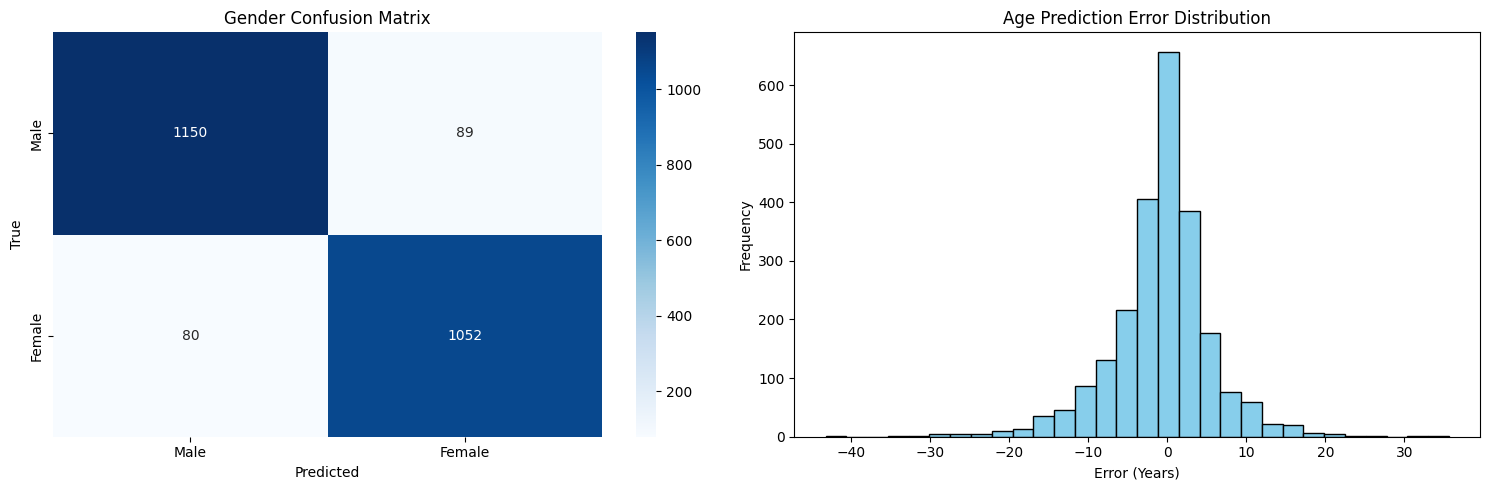

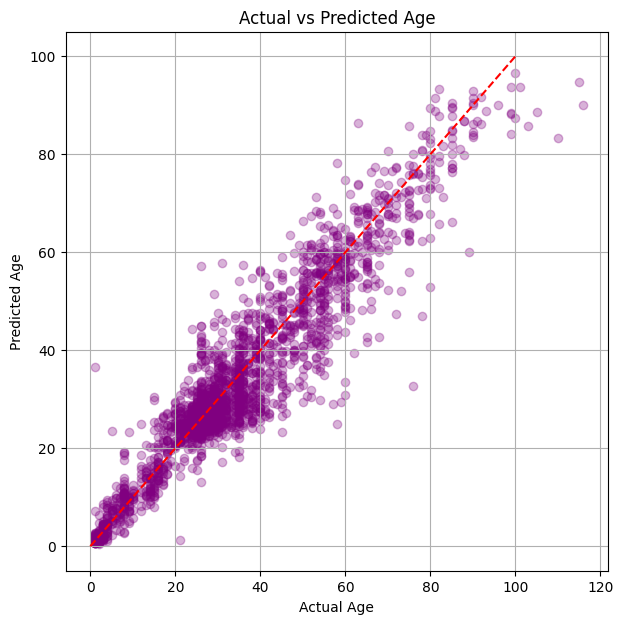

In [10]:
plt.figure(figsize=(15, 5))

# Graph 1: Confusion Matrix for Gender
plt.subplot(1, 2, 1)
cm = confusion_matrix(all_gender_true, all_gender_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Male', 'Female'], yticklabels=['Male', 'Female'])
plt.title('Gender Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

# Graph 2: Age Error Distribution
plt.subplot(1, 2, 2)
errors = all_age_preds - all_age_true
plt.hist(errors, bins=30, color='skyblue', edgecolor='black')
plt.title('Age Prediction Error Distribution')
plt.xlabel('Error (Years)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Graph 3: Actual vs Predicted Age (Scatter)
plt.figure(figsize=(7, 7))
plt.scatter(all_age_true, all_age_preds, alpha=0.3, color='purple')
plt.plot([0, 100], [0, 100], color='red', linestyle='--') # Perfect prediction line
plt.title('Actual vs Predicted Age')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.grid(True)
plt.show()


In [12]:
import shutil
import os

model_path = '/kaggle/working/best_age_gender_model_optimized.pth'
zip_path = '/kaggle/working/best_age_gender_model_optimized.zip'

if os.path.exists(model_path):
    shutil.make_archive(
        base_name='/kaggle/working/best_age_gender_model_optimized', 
        format='zip', 
        root_dir='/kaggle/working',
        base_dir='best_age_gender_model_optimized.pth'
    )
    print("✅ Zipped successfully!")
    from IPython.display import FileLink
    display(FileLink('best_age_gender_model_optimized.zip'))
else:
    print("File not found!")

✅ Zipped successfully!


/kaggle/working/best_age_gender_model_optimized.zip